# AI SCI 210 - Week 2 Tuesday

## Basic data exploration with pandas

Last time we saw an example of creating a small pandas DataFrame from a dictionary, and of creating a small pandas DataFrame from a NumPy array.  It is also common to create a DataFrame from a csv file using the `read_csv` function.  Here we'll use the penguins.csv file from the data directory.

In [2]:
import pandas as pd

In [3]:
pd.read_csv("penguins.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'penguins.csv'

In [4]:
df = pd.read_csv("data/penguins.csv")

In [5]:
type(df)

pandas.DataFrame

In [6]:
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


In [7]:
df.shape

(344, 7)

Two basic exploratory DataFrame methods are `describe` and `info`.

In [8]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


In [10]:
df.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='str')

What is the data type of an individual column in this DataFrame?

In [15]:
type(df["species"])

pandas.Series

In [11]:
df["species"].dtype

<StringDtype(storage='python', na_value=nan)>

In [12]:
df["body_mass_g"].dtype

dtype('float64')

In [17]:
df.dtype

AttributeError: 'DataFrame' object has no attribute 'dtype'

One of the exploratory methods I use most often with pandas DataFrame columns is the `value_counts` method.  It wouldn't be reasonable to use with a typical float column, but it makes good sense with other types of columns (this is related to the difference between ... **what** and **what**)?

In [13]:
df["species"].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [ ]:
# doesn't really make sense
df["body_mass_g"].value_counts()

body_mass_g
3800.0    12
3700.0    11
3950.0    10
3900.0    10
3550.0     9
          ..
5450.0     1
4975.0     1
4575.0     1
4375.0     1
5750.0     1
Name: count, Length: 94, dtype: int64

In [ ]:
# less helpful on a DataFrame than on a Series
df.value_counts()

species  island     bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  sex   
Adelie   Torgersen  39.1            18.7           181.0              3750.0       MALE      1
                    39.5            17.4           186.0              3800.0       FEMALE    1
                    40.3            18.0           195.0              3250.0       FEMALE    1
                    36.7            19.3           193.0              3450.0       FEMALE    1
                    39.3            20.6           190.0              3650.0       MALE      1
                                                                                            ..
Gentoo   Biscoe     47.2            13.7           214.0              4925.0       FEMALE    1
                    46.8            14.3           215.0              4850.0       FEMALE    1
                    50.4            15.7           222.0              5750.0       MALE      1
                    45.2            14.8           212.

Can we verify one of those numbers using a Boolean array?

In [18]:
df["species"]

0      Adelie
1      Adelie
2      Adelie
3      Adelie
4      Adelie
        ...  
339    Gentoo
340    Gentoo
341    Gentoo
342    Gentoo
343    Gentoo
Name: species, Length: 344, dtype: str

In [19]:
df["species"] == "Gentoo"

0      False
1      False
2      False
3      False
4      False
       ...  
339     True
340     True
341     True
342     True
343     True
Name: species, Length: 344, dtype: bool

In [20]:
(df["species"] == "Gentoo").sum()

np.int64(124)

Can we reproduce the 44.45 50-th percentile from above?

In [21]:
df["bill_length_mm"] < 44.45

0       True
1       True
2       True
3      False
4       True
       ...  
339    False
340    False
341    False
342    False
343    False
Name: bill_length_mm, Length: 344, dtype: bool

In [22]:
(df["bill_length_mm"] < 44.45).mean()

np.float64(0.49709302325581395)

## Plotting with Matplotlib

Matplotlib is the most important plotting library in Python.  There are many nice Python plotting libraries, each with their own strengths. (My personal favorites are Altair and Plotly.)  But no other plotting library is as flexible or as widely used as Matplotlib.

Typically we do not import the entire Matplotlib library, but instead import its submodule `pyplot`.   The standard abbreviation for `pyplot` is `plt`.

In [23]:
import matplotlib.pyplot as plt

There are a few different approaches to plotting in Matplotlib.  (That can make Matplotlib harder to learn than for example NumPy. When I was first learning Matplotlib, I found it difficult to internalize its syntax, because the code examples I found online often used different but similar-looking approaches.)  I prefer to use what is called the *object-oriented* interface.  The main alternative is called the *state-based* interface.

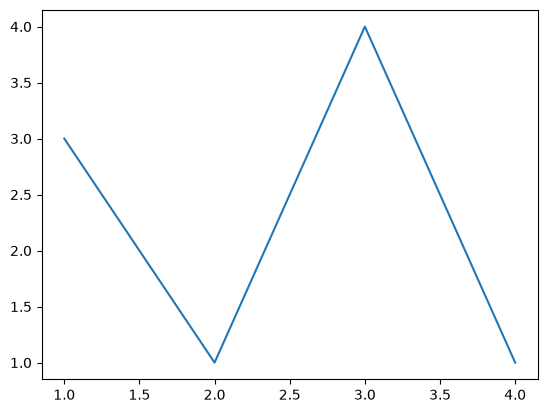

In [24]:
# state-based interface
plt.plot([1,2,3,4], [3,1,4,1])

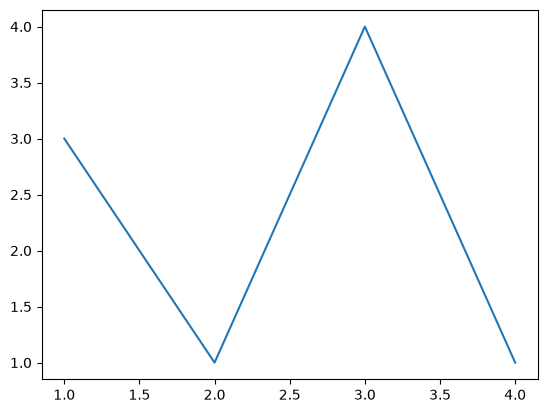

In [25]:
# object-oriented interface
fig, ax = plt.subplots()
ax.plot([1,2,3,4], [3,1,4,1])

Here let's plot a scatterplot representing the data from the penguins dataset using "bill_length_mm" for the x-coordinate and "bill_depth_mm" for the y-coordinate. 

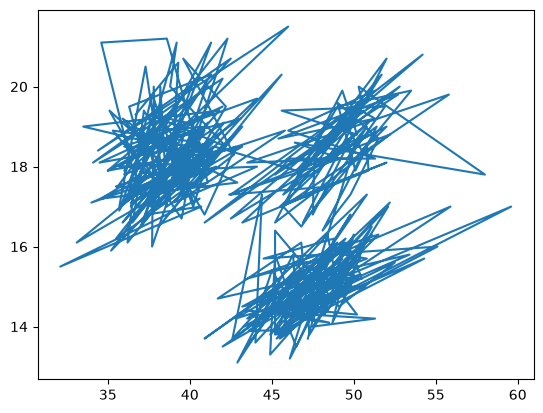

In [26]:
fig, ax = plt.subplots()
ax.plot(df["bill_length_mm"], df["bill_depth_mm"])

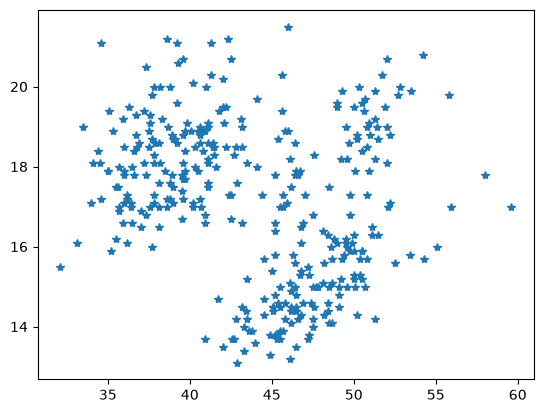

In [27]:
fig, ax = plt.subplots()
ax.plot(df["bill_length_mm"], df["bill_depth_mm"], '*')

In [30]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


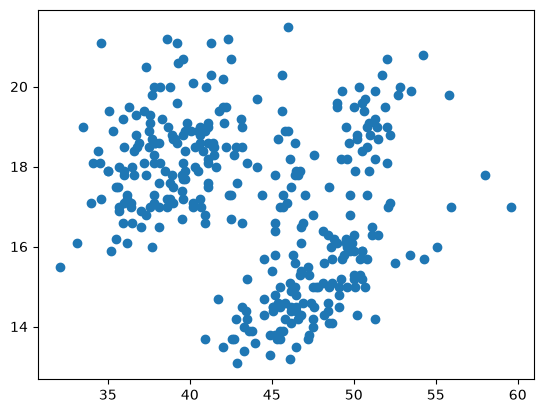

In [31]:
fig, ax = plt.subplots()
ax.scatter(df["bill_length_mm"], df["bill_depth_mm"])

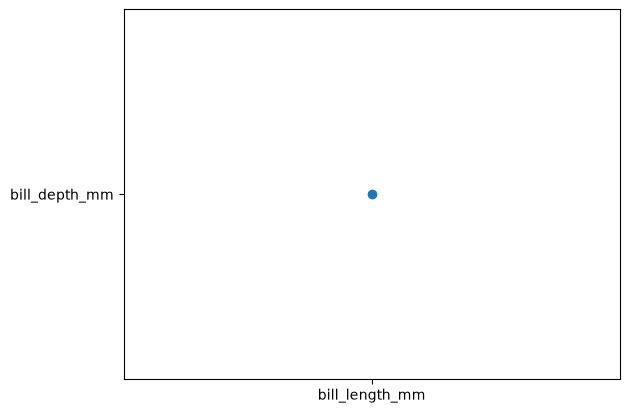

In [32]:
fig, ax = plt.subplots()
ax.scatter(x="bill_length_mm", y="bill_depth_mm")

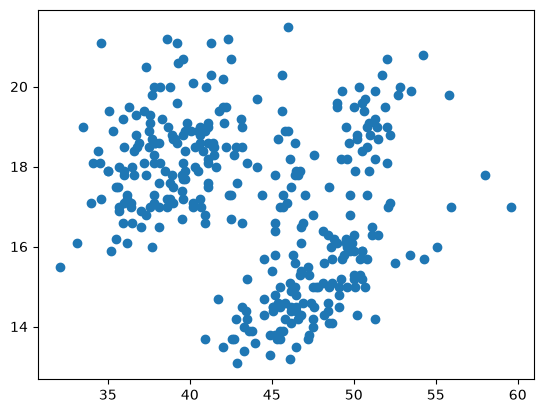

In [33]:
fig, ax = plt.subplots()
ax.scatter(x="bill_length_mm", y="bill_depth_mm", data=df)

## Plotting with Seaborn

Here we make the same scatterplot using Seaborn.

In [35]:
pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [36]:
import seaborn as sns

<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>

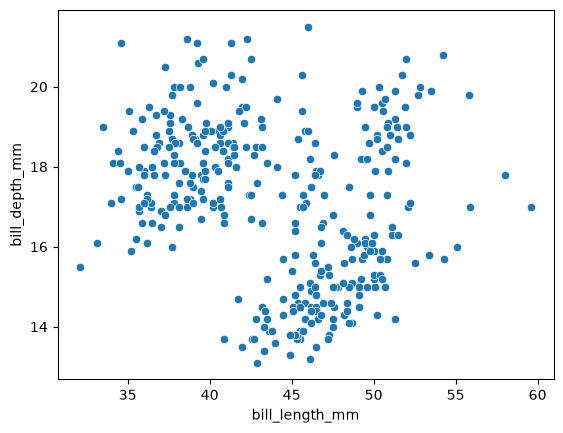

In [37]:
sns.scatterplot(x="bill_length_mm", y="bill_depth_mm", data=df)

The real advantage of Seaborn over Matplotlib is that it will automate many things for us (at the expense of being less flexible).  For example, here we add a `hue` to the scatterplot that encodes the species of penguin.

<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>

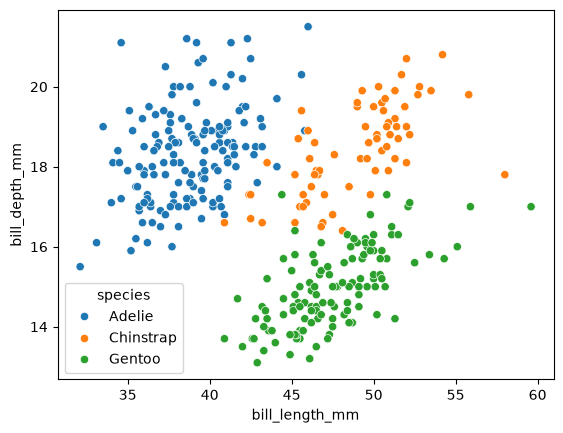

In [38]:
sns.scatterplot(x="bill_length_mm", y="bill_depth_mm", hue="species", data=df)

We can also encode something as `size`, although I tend to think less is more with this kind of plotting.

<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>

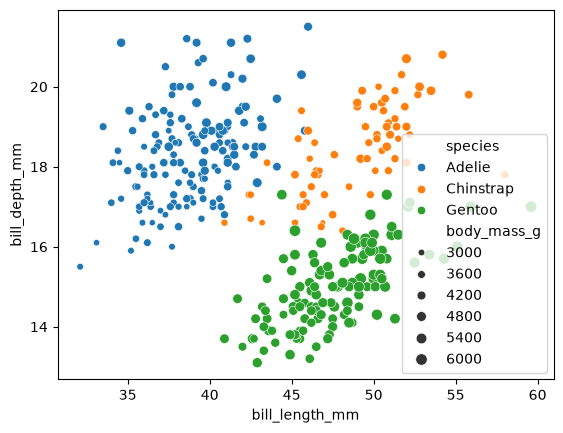

In [39]:
sns.scatterplot(x="bill_length_mm", y="bill_depth_mm", hue="species", 
                size="body_mass_g", data=df)

<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>

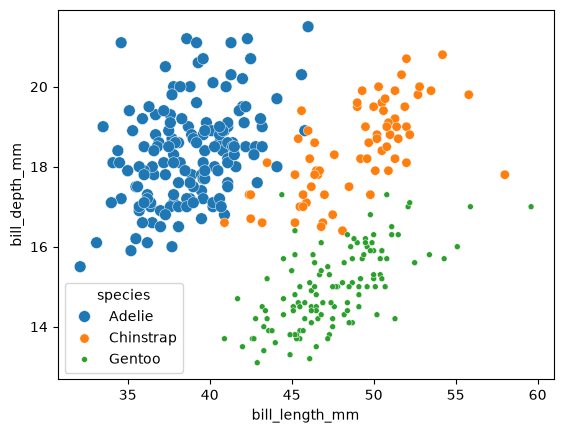

In [ ]:
# Doesn't really make sense
# should use a numeric column for size
sns.scatterplot(x="bill_length_mm", y="bill_depth_mm", hue="species", 
                size="species", data=df)

## Random numbers

Generate 10,000 random numbers, using a normal distribution with mean 10 and standard deviation 20.  Use a seed so you get reproducible results.

In [41]:
import numpy as np

In [51]:
rng = np.random.default_rng(seed=210)

In [52]:
n = 10**4
arr = rng.normal(loc=10, scale=20, size=n)
arr

array([-10.47063686,  -0.85113076,  21.21717565, ...,   6.80859764,
        28.47593931,  22.46676095], shape=(10000,))

In [53]:
# Does this violate reproducibility?
n = 10**4
rng.normal(loc=10, scale=20, size=n)

array([-15.13366324,   5.12320682, -23.56325172, ...,  22.64068344,
        11.58250723,  -6.10884019], shape=(10000,))

In a normal distribution, we expect approximately 95.44% of samples to lie within two standard deviations of the mean.  How close are we to that for our specific 10,000 numbers?  (To answer this, we will use logic with two Boolean arrays.  In standard Python, one uses the word `and`.  In NumPy and pandas, one typically uses the symbol `&`.  Similarly for `or` vs `|` and also for `not` vs `~`.)

In [54]:
(arr > -30)

array([ True,  True,  True, ...,  True,  True,  True], shape=(10000,))

In [55]:
(arr < 50)

array([ True,  True,  True, ...,  True,  True,  True], shape=(10000,))

In [56]:
((arr > -30) & (arr < 50)).mean()

np.float64(0.9528)

Can we see the bell-curve shape of a normal distribution?

In [67]:
arr2 = rng.normal(10, 20, size=25000)

<Axes: >

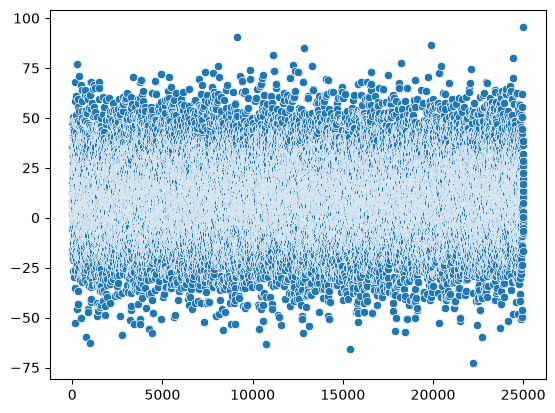

In [68]:
sns.scatterplot(arr2)

<Axes: ylabel='Count'>

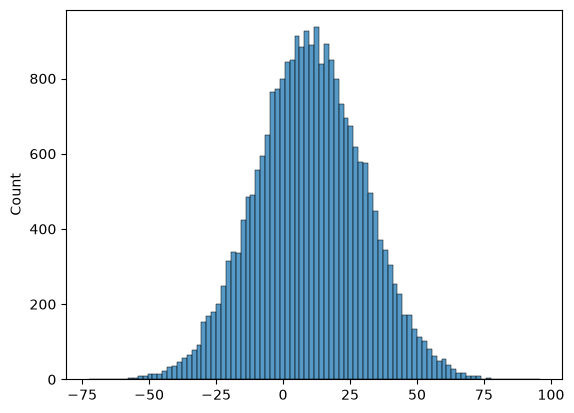

In [69]:
# histogram makes it clearer
sns.histplot(arr2)

<Axes: ylabel='Density'>

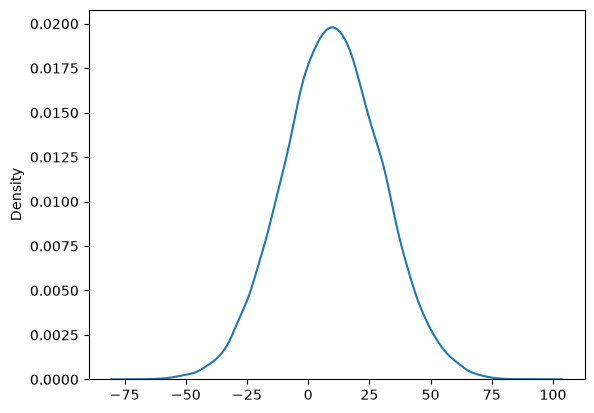

In [70]:
sns.kdeplot(arr2)

## Plots of timings

Let's see visually how search speeds can differ.  We will search with respect to the following lengths.

In [55]:
lengths = range(10**6, 2*10**7, 2*10**6)

Here we consider getting the value associated to a certain key in a dictionary.  Let's choose a key that was added "near the end" of the dictionary, just in case earlier keys are easier to find.  (Reminder that dictionaries, like sets, don't have a notion of 0-th element, etc.)

Here we consider searching for an element that occurs near the end of a list.